In [1]:
#%pip uninstall pycaret

In [2]:
# load dataset
from pycaret.datasets import get_data
insurance = get_data('insurance')

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Experiment 1

In [4]:
# init environment
from pycaret.regression import *
r1 = setup(insurance, target = 'charges', session_id = 123,)

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1338, 7)"
4,Transformed data shape,"(1338, 10)"
5,Transformed train set shape,"(936, 10)"
6,Transformed test set shape,"(402, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


In [7]:
# train a model
lr = create_model('lr')

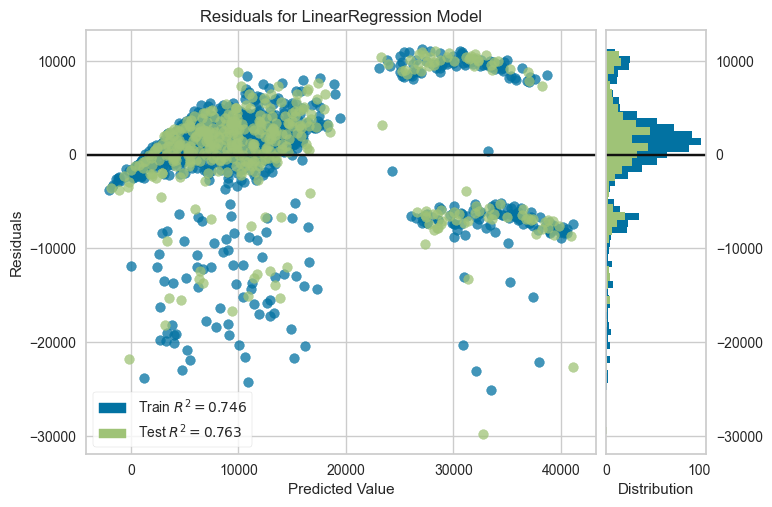

In [6]:
plot_model(lr)

Experiment 2

In [8]:
r2 = setup(insurance, target = 'charges', session_id = 123,
           normalize = True,
           polynomial_features = True)

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1338, 7)"
4,Transformed data shape,"(1338, 55)"
5,Transformed train set shape,"(936, 55)"
6,Transformed test set shape,"(402, 55)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


In [9]:
lr2 = create_model('lr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3014.5362,21463332.0468,4632.8536,0.8718,0.3837,0.3071
1,3364.4872,32827730.1557,5729.5489,0.8091,0.4369,0.2999
2,3116.8759,22970004.7769,4792.7033,0.7092,0.5036,0.3938
3,2870.2843,19994028.7757,4471.4683,0.8331,0.4651,0.3859
4,3123.4222,28296012.3147,5319.3996,0.7895,0.5087,0.2949
5,3145.4696,24102467.3290,4909.4264,0.8450,0.4767,0.3103
6,2766.7113,22064408.8946,4697.2768,0.8499,0.3768,0.2954
7,3419.0295,29936458.6272,5471.4220,0.8354,0.4557,0.2934
8,3334.4824,25780092.2943,5077.4100,0.8335,0.4241,0.3639


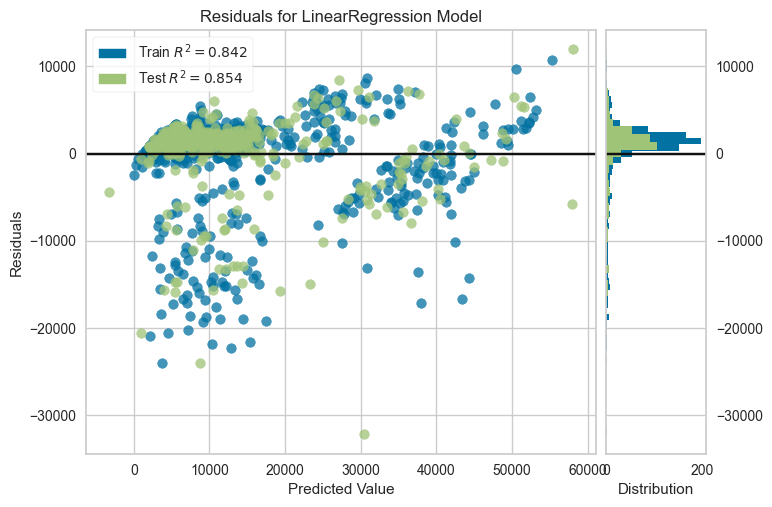

In [10]:
plot_model(lr2)

In [11]:
# save pipeline/model
save_model(lr, model_name = 'deployment_20260403_yan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['age', 'bmi', 'children'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['sex', 'smoker', 'region'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('ordinal_encoding',
                  TransformerWrapper(include=['sex', 'smoker'],
                                     transfor...
                 ('onehot_encoding',
                  TransformerWrapper(include=['region'],
                                     transformer=OneHotEncoder(cols=['region'],
                                                               handle_missing='return_nan',
                                                               use_cat_names=True))),
                 ('polynomial_features',
                  Transformer

In [12]:
deployment_20260403_yan = load_model('deployment_20260403_yan')

Transformation Pipeline and Model Successfully Loaded


In [13]:
deployment_20260403_yan

Pipeline(memory=FastMemory(location=C:\Users\david\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['age', 'bmi', 'children'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['sex', 'smoker', 'region'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encoding',
                 TransformerW...
                ('onehot_encoding',
                 TransformerWrapper(include=['region'],
                                    transformer=OneHotEncoder(cols=['region'],
                                                              handle_missing='return_nan',
                                                              use_cat_names=True))),
                ('polynomial_features',
                 TransformerWrapper(transformer=PolynomialFeatures(include_bias=False))),
                ('normalize', TransformerWrapper(transformer=StandardScaler())),
                ('trained_model', LinearRegression(n_jobs=-1))])